In [2]:
import pandas as pd 
df = pd.read_csv('../Dataset/Loan_default.csv')
df = df.drop('LoanID', axis = 1)
df.shape

(255347, 17)

## Business Objective & Cost Asymmetry

Rows: 255347

Objective:
Minimize expected loss from loan defaults.

Cost asymmetry:
- False Negative (approve defaulter) >> False Positive (reject good borrower much better then bad borrower loan approval)
- Hence recall for defaulters is prioritized over raw accuracy.

EDA implication:
- Focus on features that sharply separate high-risk segments
- Evaluate metrics insensitive to class imbalance (ROC-AUC, KS)


## Data Leakage Check

Data leakage occurs when a feature contains information that would not be available at prediction time, leading to inflated model performance.

### Interest Rate
`InterestRate` is removed because it is typically assigned after internal risk assessment and loan approval. Including it would leak the lender’s decision logic into the model.

### Debt-to-Income (DTI) Ratio
`DTIRatio` may be safe or leaky depending on its timing:
- Pre-loan DTI (based on existing obligations): safe
- Post-loan DTI (includes approved EMI): leakage

Since the dataset has no rows with positive DTI and no loan assigned. 


In [3]:
import numpy as np
suspect_dti = df[
    ((df['LoanAmount'] == 0) | (df['LoanAmount'].isna())) &
    (df['DTIRatio'] > 0)
]

print("Rows with no loan but positive DTI:", len(suspect_dti))
suspect_dti.head()


Rows with no loan but positive DTI: 0


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default


The absence of positive DTI values for zero-loan observations indicates that DTIRatio is calculated post-approval and therefore introduces data leakage in an application-time default prediction model.


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  str    
 10  EmploymentType  255347 non-null  str    
 11  MaritalStatus   255347 non-null  str    
 12  HasMortgage     255347 non-null  str    
 13  HasDependents   255347 non-null  str    
 14  LoanPurpose     255347 non-null  str    
 15  HasCoSigner     255347 non-null  str    
 16  Default         255347 non-null  int64  
dtypes: float64(2), int64(

In [5]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [6]:
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].unique())



Education:
<ArrowStringArray>
['Bachelor's', 'Master's', 'High School', 'PhD']
Length: 4, dtype: str

EmploymentType:
<ArrowStringArray>
['Full-time', 'Unemployed', 'Self-employed', 'Part-time']
Length: 4, dtype: str

MaritalStatus:
<ArrowStringArray>
['Divorced', 'Married', 'Single']
Length: 3, dtype: str

HasMortgage:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

HasDependents:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

LoanPurpose:
<ArrowStringArray>
['Other', 'Auto', 'Business', 'Home', 'Education']
Length: 5, dtype: str

HasCoSigner:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


In [7]:
df['Default'].value_counts(normalize=True) * 100

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

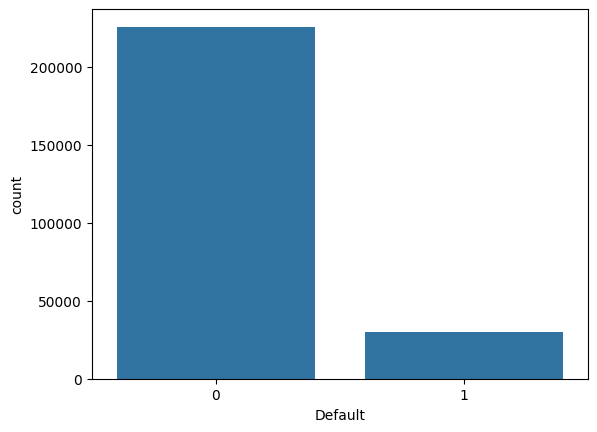

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt 
sns.countplot(x='Default', data=df)
plt.show()


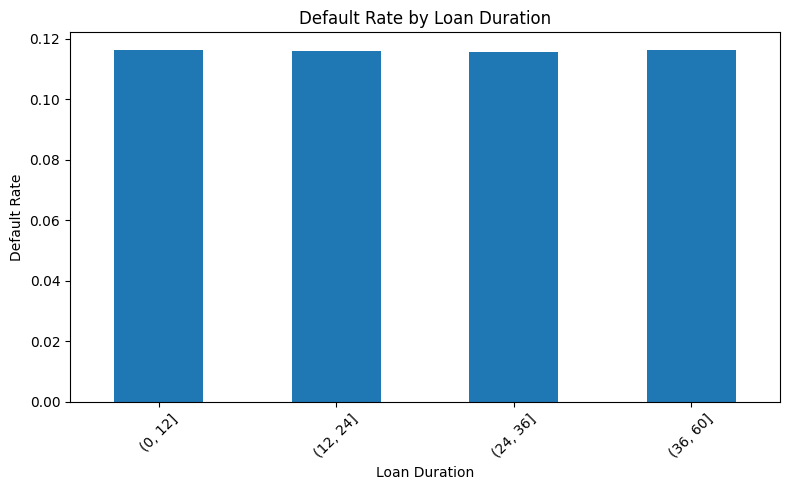

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Bin and calculate default rate
bins = [0, 12, 24, 36, 60, 120]
df['loan_duration_bin'] = pd.cut(df['LoanTerm'], bins=bins)
default_by_duration = df.groupby('loan_duration_bin', observed = True)['Default'].mean()

# Plot
default_by_duration.plot(kind='bar', figsize=(8, 5))
plt.xlabel('Loan Duration')
plt.ylabel('Default Rate')
plt.title('Default Rate by Loan Duration')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

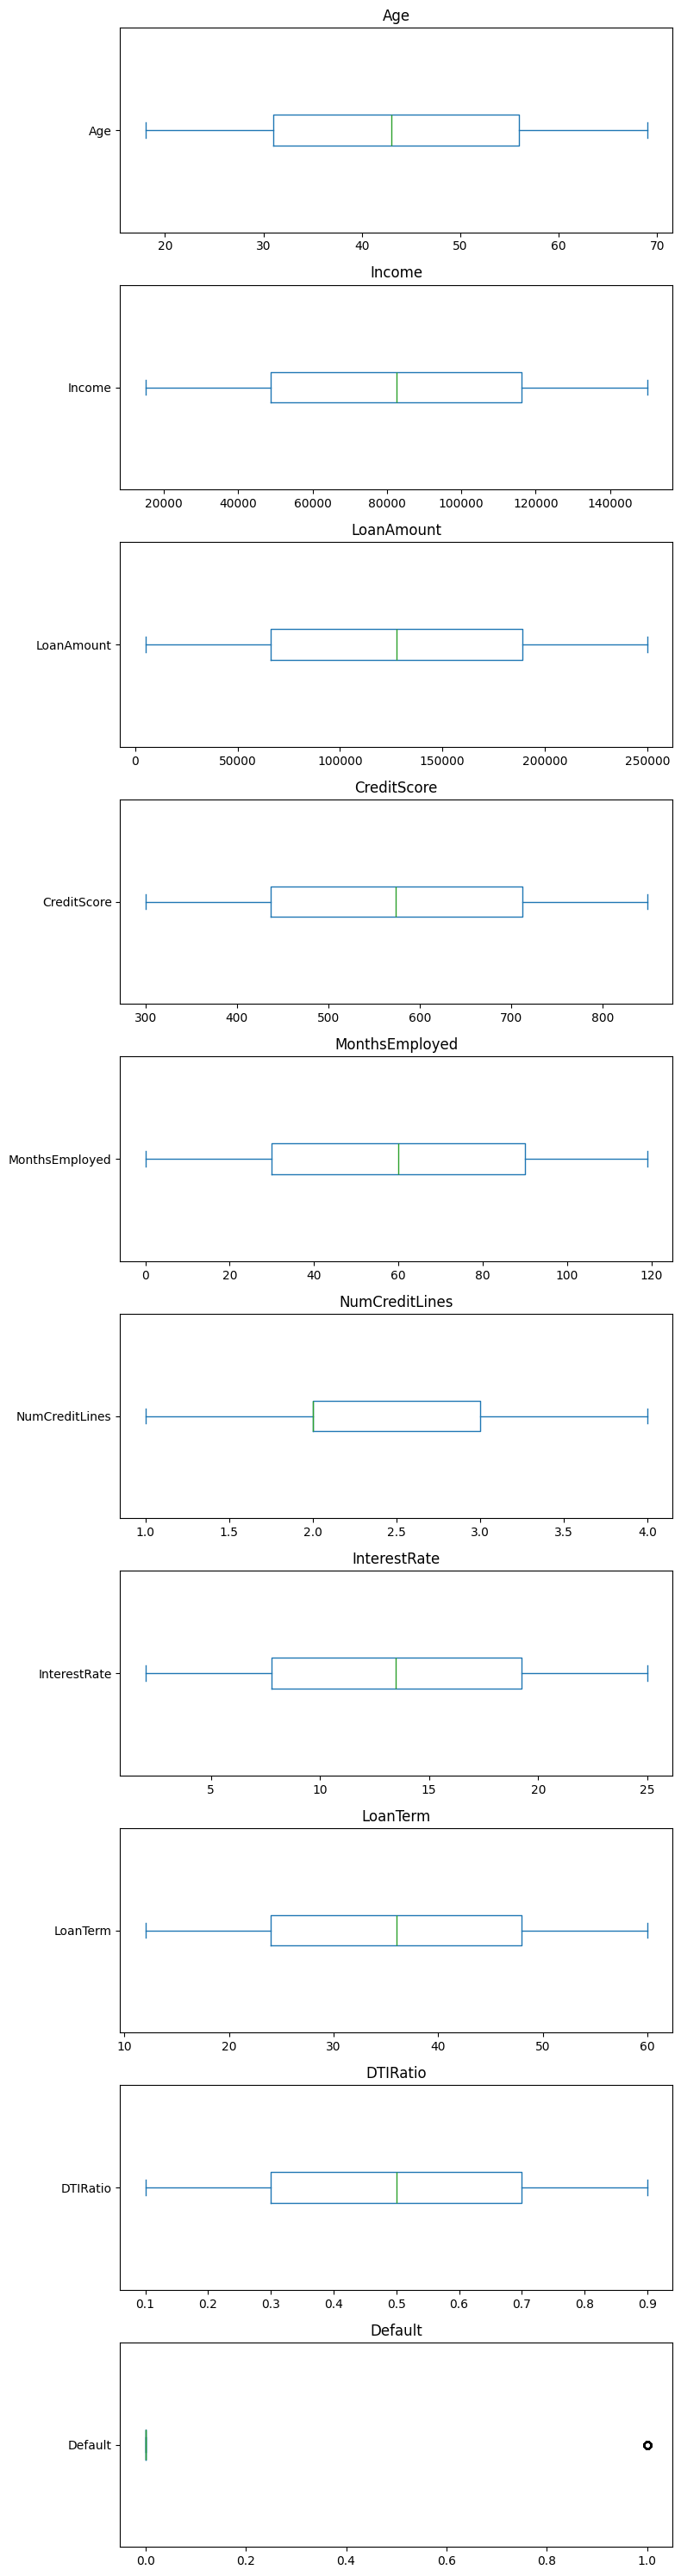

In [10]:
import matplotlib.pyplot as plt

# Get numerical columns
num_cols = df.select_dtypes(include='number').columns

# Create boxplots
fig, axes = plt.subplots(len(num_cols), 1, figsize=(8, 3*len(num_cols)))
for i, col in enumerate(num_cols):
    df[col].plot(kind='box', ax=axes[i], vert=False)
    axes[i].set_title(f'{col}')
plt.tight_layout()
plt.show()

Dataset looks to be very evenly distributed indicating artifical dataset 

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28088\781235634.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


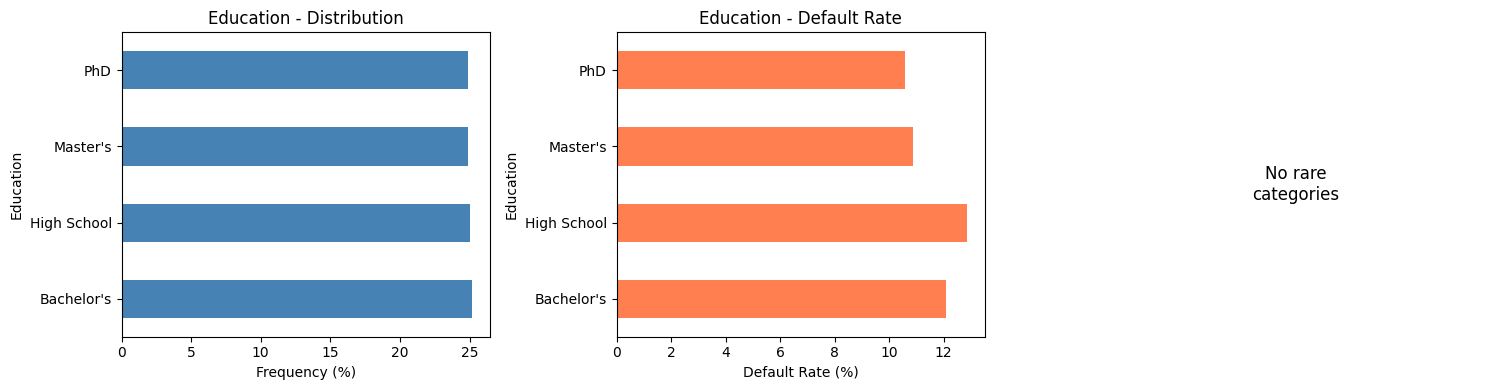

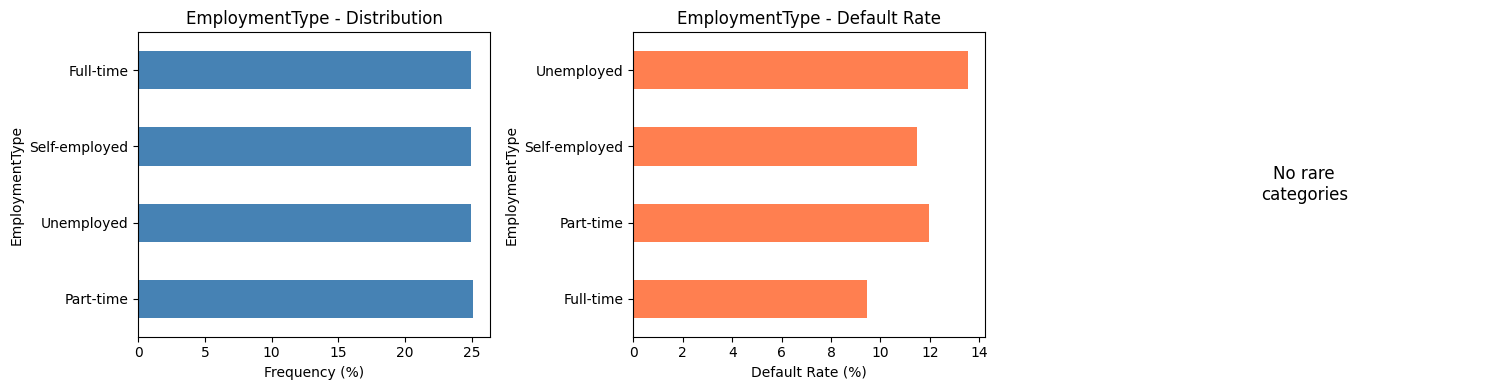

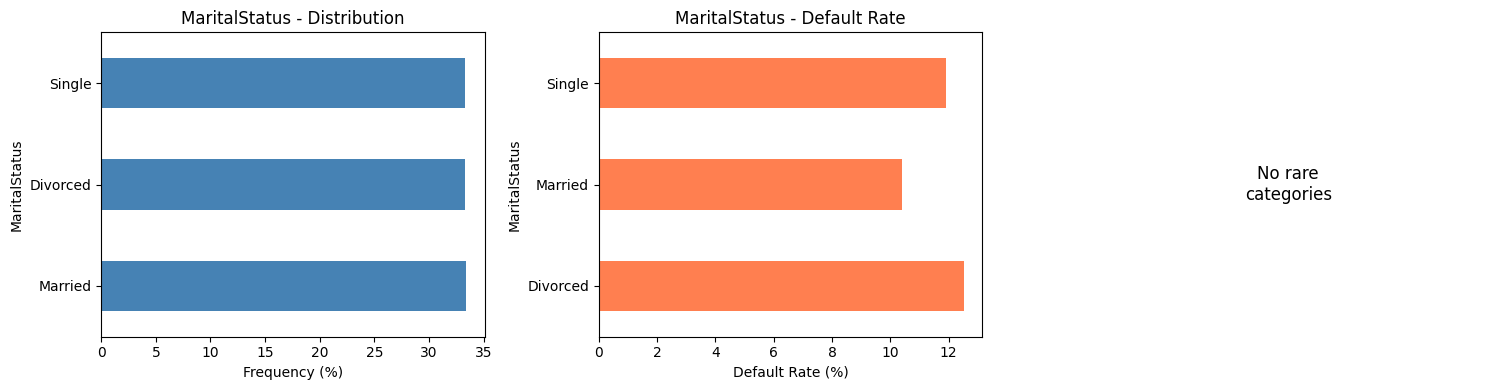

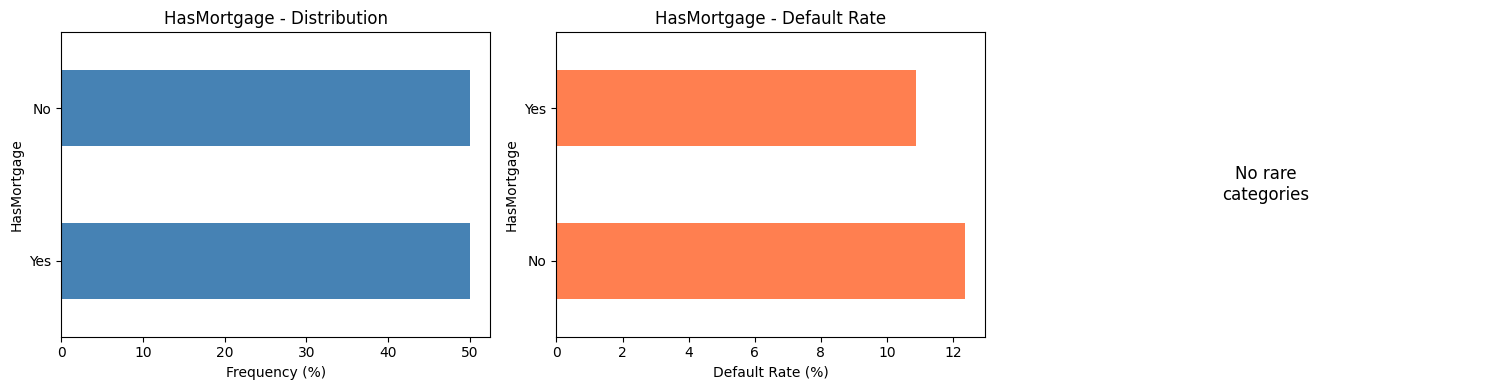

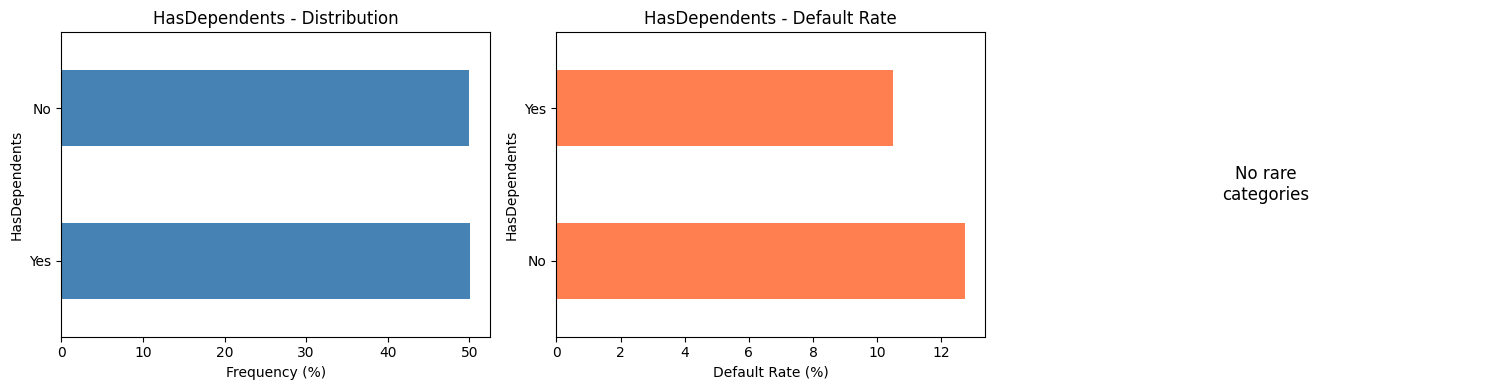

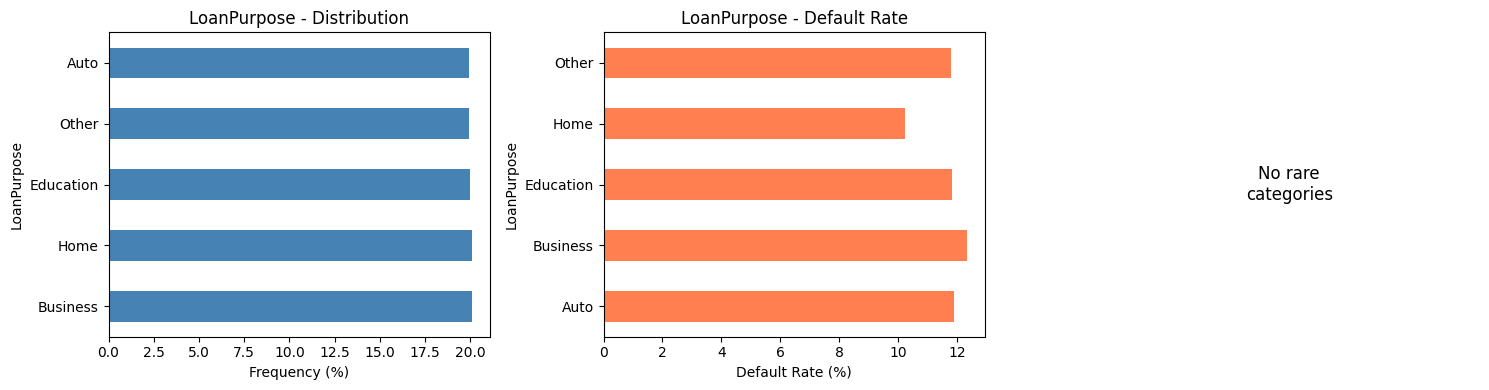

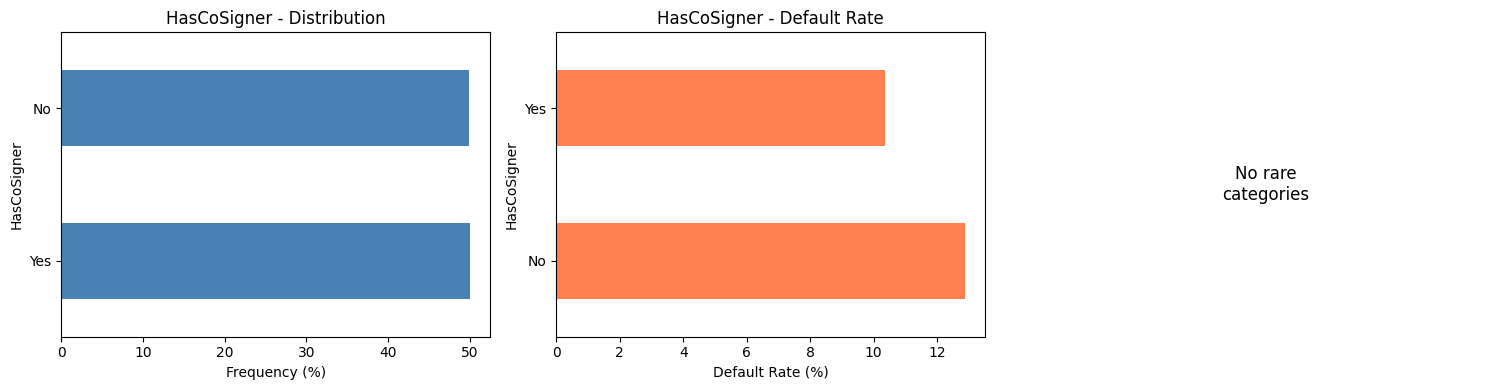

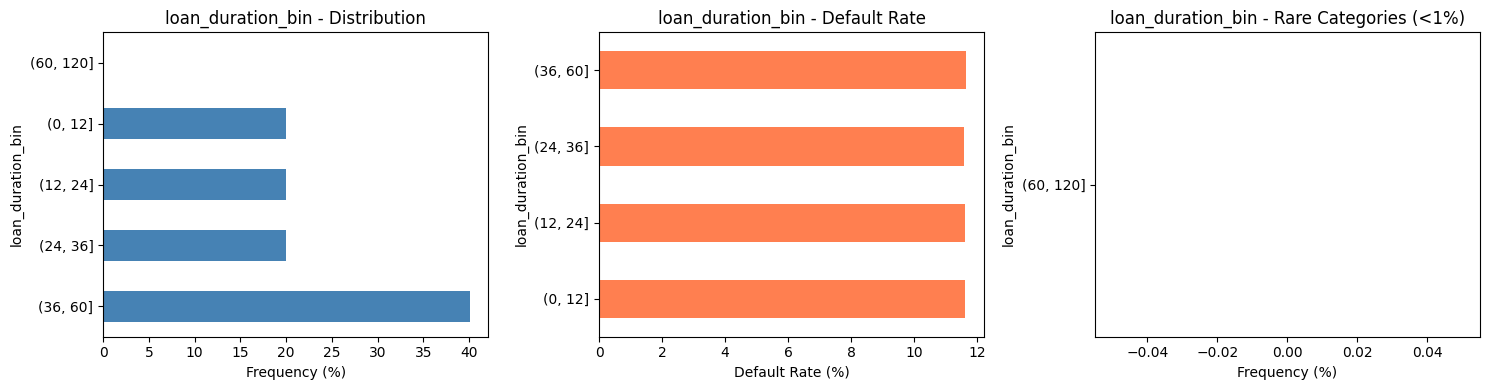

In [11]:
import matplotlib.pyplot as plt
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    # Calculate metrics
    freq = df[col].value_counts(normalize=True) * 100
    default_rate = df.groupby(col, observed=True)['Default'].mean() * 100
    rare = freq[freq < 1]

    # Create visualizations
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Frequency
    freq.plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_xlabel('Frequency (%)')
    axes[0].set_title(f'{col} - Distribution')

    # Default rate
    default_rate.plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_xlabel('Default Rate (%)')
    axes[1].set_title(f'{col} - Default Rate')

    # Rare categories
    if len(rare) > 0:
        rare.plot(kind='barh', ax=axes[2], color='tomato')
        axes[2].set_xlabel('Frequency (%)')
        axes[2].set_title(f'{col} - Rare Categories (<1%)')
    else:
        axes[2].text(0.5, 0.5, 'No rare\ncategories', 
                     ha='center', va='center', fontsize=12)
        axes[2].axis('off')

    plt.tight_layout()
    plt.show()

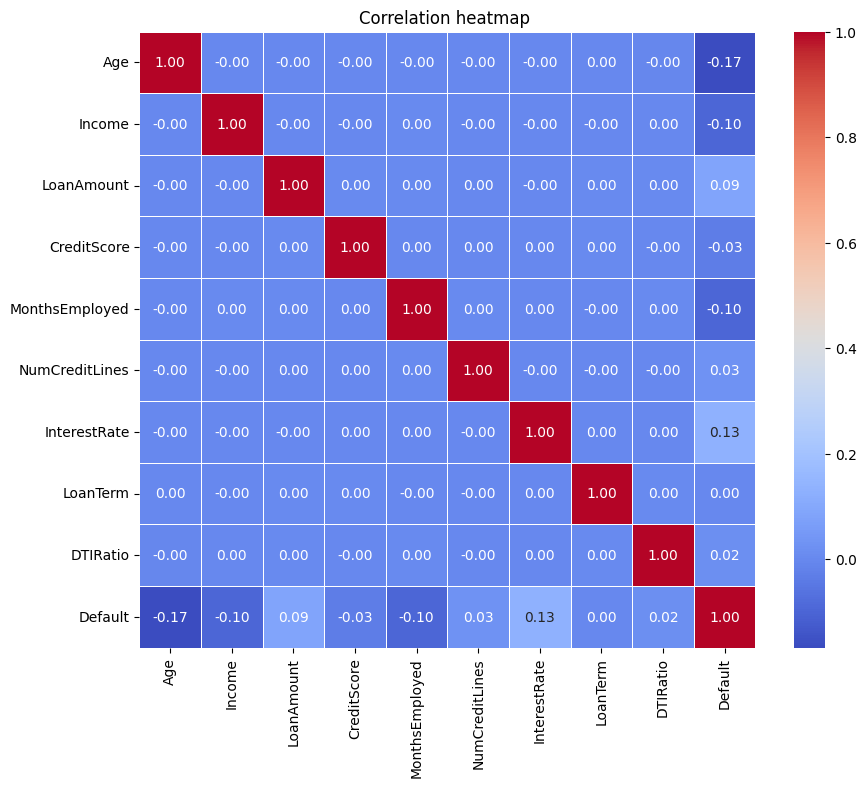

In [12]:
import seaborn as sns 
import matplotlib.pyplot as plt 

# heatmap for numerical features
corr_mat = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation heatmap ")
plt.show()

# Finding Kurtosis and Skewness  

In [13]:
df_skew = df.select_dtypes(include="number").skew()
df_kurt = df.select_dtypes(include="number").kurt()

summary = pd.DataFrame({
    "Skewness":df_skew,
    "Kurtosis":df_kurt
})

summary

,Skewness,Kurtosis
Age,0.000698,-1.198431
Income,-0.000381,-1.198361
LoanAmount,-0.001827,-1.203680
CreditScore,0.004688,-1.200302
MonthsEmployed,-0.002142,-1.199632
NumCreditLines,-0.000278,-1.357671
InterestRate,0.004608,-1.197167
LoanTerm,-0.002178,-1.299895
DTIRatio,-0.001499,-1.199675
Default,2.396377,3.742652


# Major findings 
1. The dataset looks very uniformly distributed with no missing values this looking a lot like a dataset that is artificially generated
2. There is almost no numerical correaltion between any numeric features as given above (no value above 0.15)
3. DTI looks strongly like feature leaking as it is calculated most probably after the loan has been sanctioned
4. even after binning using time and interest rate there is no business indication for the data suggesting a skew 
5. very low values for kurtosis and skewness (except Default as it is imbalanced) mean that the data has very small extremes and no major outlier distribution 